In [1]:
# Basic includes
%matplotlib inline
import numpy as np
import sys, os
import colorcet as cc

sys.path.append('/global/homes/m/millerk1/pyVisOS/')

import osh5io
import osh5def
import osh5vis
import osh5utils
import osh5visipy
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.signal import hilbert

Importing osh5visipy. Please use `%matplotlib notebook' in your jupyter/ipython notebook;
use `%matplotlib widget' if you are using newer version of matplotlib (3.0) + jupyterlab (0.35)


In [2]:
# This is a bit esoteric, but I like to use the font Latin Modern Roman, which looks just like the TeX font.
# I've downloaded that font and placed it in a folder in my home directory.  I've included it in the Notion
# document, so feel free to copy it to your directory and use this as well.
for font in mpl.font_manager.findSystemFonts('/global/homes/m/millerk1/custom-fonts/'):
    mpl.font_manager.fontManager.addfont(font)
plt.rcParams["figure.facecolor"] = (1,1,1,1)
mpl.rcParams['font.serif'] = 'Latin Modern Roman'
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['mathtext.rm'] = 'serif'

# Store the default color cycle of lines from matplotlib.  That way I can easily set text or something
# to this color with the command color=clrs[2], etc.
clrs=plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
# Some custom colormap utilities.

# Useful for putting the middle of the colorbar at zero for, say, when you have
# data that extends between [-4, 6], and you want to include all of it and not
# limit to [-6, 6].
def mid_norm(im, midpoint=0.0):
    """
    Re-center an image's colormap around a specified midpoint.

    Parameters
    ----------
    im : matplotlib.image.AxesImage
        The image object returned by functions such as `imshow`.
    midpoint : float, optional
        The data value that should map to the center of the colormap.
        Default is 0.0.
    """
    vmin, vmax = im.get_clim()
    cmap = im.get_cmap()
    norm = mpl.colors.TwoSlopeNorm(midpoint)
    # newcmp = colors.ListedColormap(cmap(norm(np.linspace(vmin, vmax, int(256*np.max([vmax-midpoint,midpoint-vmin])/(vmax-vmin)/0.5)))))
    newcmp = mpl.colors.ListedColormap(cmap(norm(np.linspace(vmin, vmax, 256))))
    im.set_cmap(newcmp)


# Now let's make some custom colormaps
def make_colormap(cmap_def, name, reg, intrude, power):
    """
    Create and register a custom colormap (and its reverse) that modifies the
    lower portion of an existing colormap with a smooth transition toward white.

    Parameters
    ----------
    cmap_def : matplotlib.colors.Colormap
        Base colormap used to generate the custom colormap.
    name : str
        Name under which the new colormap will be registered.
    reg : int
        Number of indices over which the lower colormap modification is applied.
    intrude : int
        Index in the original colormap of how far to intrude (excludes colors).
    power : float
        Exponent controlling the smoothness of the transition toward white.
    """
    if name not in plt.colormaps():
        vals = cmap_def(np.arange(cmap_def.N))
        inds = np.arange(reg)
        dat_lower = vals[inds,:]
        dat_lower[:,:3] = np.tile(vals[intrude,:3],(reg,1)) + (1-np.tile(vals[intrude,:3],(reg,1))) * np.power(1-np.tile(inds/reg,(3,1)).T,power)
        cmap_cust = mpl.colors.ListedColormap(np.vstack((dat_lower,vals[intrude:,:])), N=cmap_def.N+reg-intrude, name=name)
        mpl.colormaps.register(cmap_cust)
        cmap_cust = mpl.colors.ListedColormap(np.flip(np.vstack((dat_lower,vals[intrude:,:])),axis=0), N=cmap_def.N+reg-intrude, name=name+'_r')
        mpl.colormaps.register(cmap_cust)


def make_colormap_middle(cmap_def, name, reg, power):
    """
    Create and register a custom colormap (and its reverse) that symmetrically
    modifies the central region of an existing colormap toward white.

    Parameters
    ----------
    cmap_def : matplotlib.colors.Colormap
        Base colormap used to generate the custom colormap.
    name : str
        Name under which the new colormap will be registered.
    reg : int
        Number of indices on each side of the colormap center to modify.
    power : float
        Exponent controlling the smoothness of the transition toward white.
    """
    if name not in plt.colormaps():
        vals = cmap_def(np.arange(cmap_def.N))
        inds1 = np.arange(int(cmap_def.N/2),int(cmap_def.N/2)+reg)
        vals[inds1,:3] = vals[inds1,:3] + (1-vals[inds1,:3]) * np.power(1-np.tile((inds1-inds1[0])/reg,(3,1)).T,power)
        inds2 = np.arange(int(cmap_def.N/2)-reg,int(cmap_def.N/2))
        vals[inds2,:3] = vals[inds2,:3] + (1-vals[inds2,:3]) * np.power(1-np.tile(np.abs(inds2-inds2[-1])/reg,(3,1)).T,power)
        cmap_cust = mpl.colors.ListedColormap(vals, N=cmap_def.N, name=name)
        mpl.colormaps.register(cmap_cust)
        cmap_cust = mpl.colors.ListedColormap(np.flip(vals,axis=0), N=cmap_def.N, name=name+'_r')
        mpl.colormaps.register(cmap_cust)

# Create a bunch of high-quality, perceptually uniform colormaps that go to complete white at the edge or middle.
# My favorites are shown in the cells below.
make_colormap( cc.m_rainbow, 'Rainbow', 20, 0, 1.5 )
make_colormap( cc.m_rainbow4, 'Rainbow4', 20, 0, 1.5 )
make_colormap( cc.m_bgy, 'BGY', 20, 0, 1.5 )
make_colormap( cc.m_gouldian, 'Gouldian', 20, 0, 1.5 )
make_colormap( cc.m_bmw, 'BMW', 20, 0, 1.5 )
make_colormap( cc.m_bmy, 'BMY', 20, 0, 1.5 )
make_colormap( cc.m_linear_kry_5_95_c72, 'Fire', 20, 0, 1.5 )
make_colormap_middle( mpl.cm.jet, 'Jet', 15, 2.0 )
make_colormap_middle( cc.m_CET_R3, 'Jet2', 15, 2.0 )
make_colormap_middle( cc.m_CET_D13, 'BG', 10, 2.0 )
make_colormap_middle( cc.m_CET_D1A, 'BR', 10, 2.0 )
make_colormap_middle( cc.m_gwv, 'GP', 10, 2.0 )
make_colormap_middle( cc.m_CET_D3, 'GR', 10, 2.0 )
make_colormap_middle( cc.m_CET_D10, 'BP', 10, 2.0 )
make_colormap_middle( cc.m_coolwarm, 'Coolwarm', 10, 2.0 )

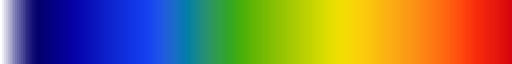

In [4]:
plt.colormaps['Rainbow4']

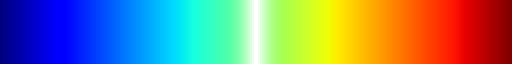

In [5]:
plt.colormaps['Jet']

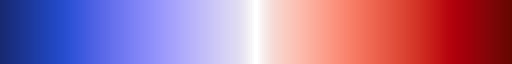

In [6]:
plt.colormaps['BR']

In [7]:
# Some utility functions for plotting.  See usage in later cells.

# Quickly adjust all font sizes in a plot
def mpl_font_size(FONT_SIZE=10):
    """
    Set global Matplotlib font sizes for figures, axes, ticks, and legends.

    Parameters
    ----------
    FONT_SIZE : int or float, optional
        Base font size applied to most plot elements. The legend font size
        is set slightly smaller (FONT_SIZE - 2). Default is 10.
    """
    plt.rc('font', size=FONT_SIZE)          # controls default text sizes
    plt.rc('axes', titlesize=FONT_SIZE)     # fontsize of the axes title
    plt.rc('axes', labelsize=FONT_SIZE)     # fontsize of the x and y labels
    plt.rc('xtick', labelsize=FONT_SIZE)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=FONT_SIZE)    # fontsize of the tick labels
    plt.rc('legend', fontsize=FONT_SIZE-2)  # legend fontsize
    plt.rc('figure', titlesize=FONT_SIZE)   # fontsize of the figure title


# Used to create alphas when plotting multiple datasets on the same plot.
def make_alphas(data, low_thr=0, high_thr=1, alpha0=1):
    """
    Generate an array of alpha (transparency) values based on data thresholds.

    Values below `low_thr` are fully transparent, values above `high_thr`
    are fully opaque (scaled by `alpha0`), and values in between are
    linearly interpolated.

    Parameters
    ----------
    data : array-like
        Input data array used to compute alpha values.
    low_thr : float, optional
        Lower threshold below which alpha is set to zero. Default is 0.
    high_thr : float, optional
        Upper threshold above which alpha is set to one. Default is 1.
    alpha0 : float, optional
        Overall scaling factor applied to the resulting alpha values. Default is 1.

    Returns
    -------
    alphas : ndarray
        Array of alpha values with the same shape as `data`.
    """
    alphas = np.ones_like(data)
    alphas[data <= low_thr] = 0.0
    alphas[np.logical_and(data > low_thr, data < high_thr)] = (
        (data[np.logical_and(data > low_thr, data < high_thr)] - low_thr)
        / (high_thr - low_thr)
    )
    return alphas * alpha0


# Create a colorbar that reflects the alphas you added (transparency doesn't look right).
def alpha_colorbar(curr_map, low_thr=0, high_thr=1, alpha0=1, fig=None, **kwargs):
    """
    Create a colorbar with an effective alpha (transparency) gradient by
    mixing the colormap with a white background.

    Parameters
    ----------
    curr_map : matplotlib.image.AxesImage
        The image or mappable object whose colormap and normalization define the colorbar.
    low_thr : float, optional
        Lower threshold below which colors are fully blended to white. Default is 0.
    high_thr : float, optional
        Upper threshold above which colors are fully opaque. Default is 1.
    alpha0 : float, optional
        Overall scaling factor applied to the alpha blending. Default is 1.
    fig : matplotlib.figure.Figure, optional
        Figure object to which the colorbar is attached. If None, the current figure is used.
    **kwargs
        Additional keyword arguments passed to `plt.colorbar` or `fig.colorbar`.

    Returns
    -------
    cb : matplotlib.colorbar.Colorbar
        The resulting colorbar object.
    """
    # Choose colormap
    cmap = curr_map.get_cmap()
    # Get the colormap colors
    vmin=curr_map.get_clim()[0]; vmax=curr_map.get_clim()[1]
    my_cmap = cmap(curr_map.norm(np.linspace(vmin,vmax,cmap.N)))
    # Set alpha
    cmap_vals = np.abs(np.linspace(vmin,vmax,cmap.N))
    alphas = np.ones_like(cmap_vals)
    alphas[cmap_vals<=low_thr] = 0.0
    alphas[np.logical_and(cmap_vals>low_thr,cmap_vals<high_thr)] = (cmap_vals[np.logical_and(cmap_vals>low_thr,cmap_vals<high_thr)]
                                                                    -low_thr)/(high_thr-low_thr)
    alphas = alphas*alpha0
    # Setting the alphas themselves produces white lines in the colorbar
    # my_cmap[:,-1] = alphas
    # Instead we mix in white to the colorbar
    # Define the background as white
    BG = np.asarray([1., 1., 1.,])
    # Mix the colors with the background
    for i in range(cmap.N):
        my_cmap[i,:-1] = my_cmap[i,:-1] * alphas[i] + BG * (1.-alphas[i])
    # Create new colormap which mimics the alpha values
    my_cmap = mpl.colors.ListedColormap(my_cmap)
    if fig is None:
        cb = plt.colorbar(mappable=mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=curr_map.get_clim()[0],vmax=curr_map.get_clim()[1]),
                                                         cmap=my_cmap), ax=curr_map.axes, **kwargs)
    else:
        cb = fig.colorbar(mappable=mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=curr_map.get_clim()[0],vmax=curr_map.get_clim()[1]),
                                                         cmap=my_cmap), ax=curr_map.axes, **kwargs)
    return cb

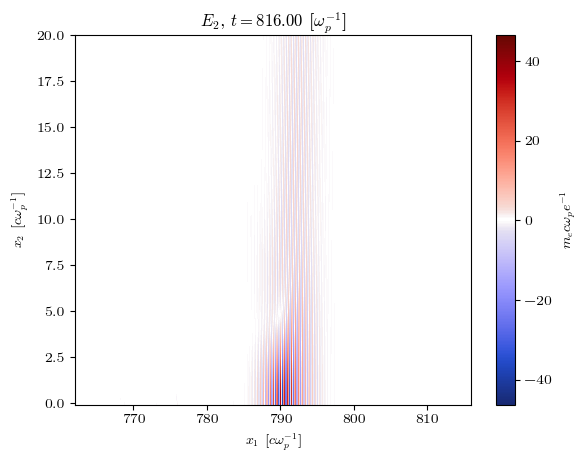

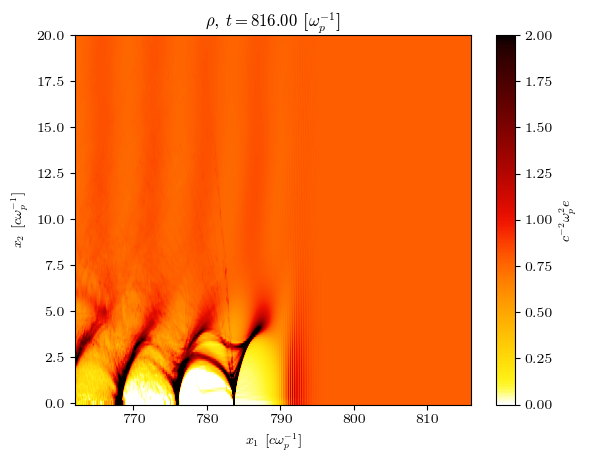

In [8]:
# Plotting commands I use 90% of the time

n=40

# Visualize an electric field, setting the midpoint to white (and using our custom colormap)
c=osh5io.read_h5(f'charlie/r-scans/r-1.000/MS/FLD/MODE-1-RE/e2_cyl_m/e2_cyl_m-1-re-{n:06d}.h5')
plt.figure()
im, _ = osh5vis.osplot(c,cmap='BR')
plt.ylim(top=20)
mid_norm(im)
plt.show()

# My go-to colormap for density plots
c=osh5io.read_h5(f'charlie/r-scans/r-1.000/MS/DENSITY/electrons/MODE-0-RE/charge_cyl_m/charge_cyl_m-electrons-0-re-{n:06d}.h5')
plt.figure()
im, _ = osh5vis.osplot(np.abs(c),cmap='cet_fire_r', vmax=2.0)
plt.ylim(top=20)
plt.show()

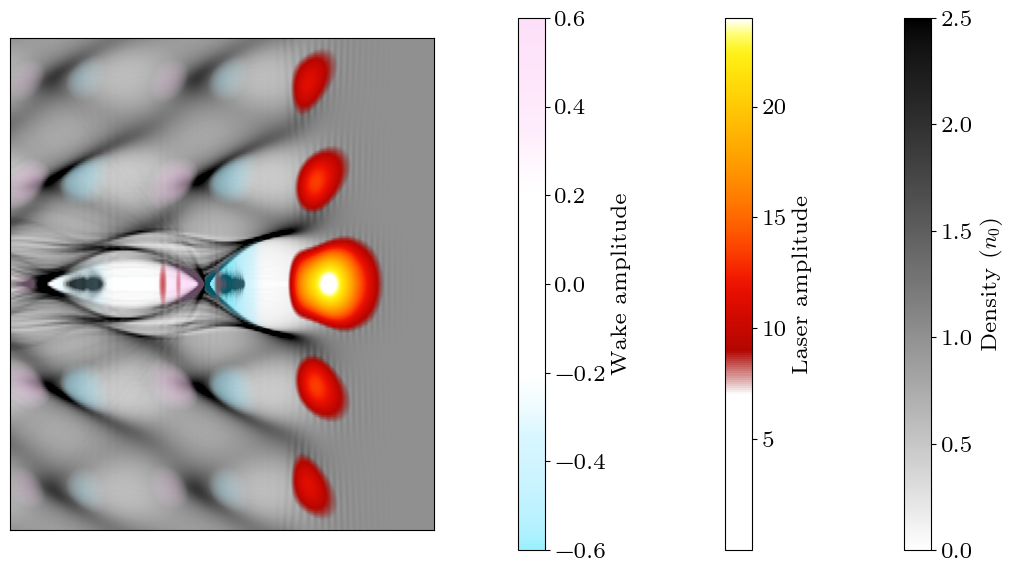

In [9]:
# Example usage of the make_alphas command to plot multiple datasets in a single 2D color plot
laser=osh5io.read_h5('/global/cfs/cdirs/m4372/const-focus/c-80/MS/FLD/MODE-1-RE/e2_cyl_m/e2_cyl_m-1-re-{:06d}.h5'.format(268))
laser.values = np.abs(hilbert(laser.values,axis=-1))
den_back=osh5io.read_h5('/global/cfs/cdirs/m4372/const-focus/c-80/MS/DENSITY/electrons/MODE-0-RE/charge_cyl_m/charge_cyl_m-electrons-0-re-{:06d}.h5'.format(268))
den_inj=osh5io.read_h5('/global/cfs/cdirs/m4372/const-focus/c-80/MS/DENSITY/Ar9-14electrons/MODE-0-RE/charge_cyl_m/charge_cyl_m-Ar9-14electrons-0-re-{:06d}.h5'.format(268))
wake=osh5io.read_h5('/global/cfs/cdirs/m4372/const-focus/c-80/MS/FLD/MODE-0-RE/e1_cyl_m/e1_cyl_m-0-re-{:06d}.h5'.format(268))

den_all = den_back + den_inj
den_refl = np.concatenate((np.flip(den_all.values[1:,:],axis=0),den_all.values[1:,:]),axis=0)
laser_refl = np.concatenate((np.flip(laser.values[1:,:],axis=0),laser.values),axis=0)
wake_refl = np.concatenate((np.flip(wake.values[1:,:],axis=0),wake.values[1:,:]),axis=0)
c_wp = 2.00854e-6
z_zero = 0.0086733/c_wp
wake_refl[:,wake.axes[1].ax>=z_zero] = 0


# Make all fonts bigger
mpl_font_size(16)
ext = np.array([den_all.axes[1].min,den_all.axes[1].max,-den_all.axes[0].max,den_all.axes[0].max])*c_wp
# ext[:2] = ext[:2] - 4325*c_wp
plt.figure(figsize=(11,6))

plt.imshow(np.abs(den_refl),extent=ext,cmap='cet_gray_r',vmax=2.5,aspect='equal')
plt.colorbar(label='Density ($n_0$)')

# Turn on from transparent to opaque from 7 to 9
thr = [7,9]
alphas = make_alphas( np.abs(laser_refl), low_thr=thr[0], high_thr=thr[1] )
im=plt.imshow(laser_refl,extent=ext,cmap='cet_fire',aspect='equal',alpha=alphas,vmax=24)
# Make a colorbar that accurately reflects this trnasparency
cb2=alpha_colorbar( im, low_thr=thr[0], high_thr=thr[1], fig=plt.gcf(), label=r'Laser amplitude', pad=0.14)

# Take the absolute value of the data when making the alphas, but plot it with the signed data to have the middle be transparent
thr = [0.2,0.34]
alphas = make_alphas( np.abs(wake_refl), low_thr=thr[0], high_thr=thr[1], alpha0=0.4 )
im=plt.imshow(wake_refl,extent=ext,cmap='cet_CET_D10',aspect='equal',alpha=alphas,vmin=-0.6,vmax=0.6)
cb2=alpha_colorbar( im, low_thr=thr[0], high_thr=thr[1], fig=plt.gcf(), label=r'Wake amplitude', pad=0.14, alpha0=0.4)

plt.xlim(np.array([4306,4325])*c_wp)
plt.ylim(np.array([-11,11])*c_wp)

plt.tick_params(left = False, right = False , labelleft = False ,
                labelbottom = False, bottom = False)

plt.tight_layout()
# plt.savefig('/global/homes/m/millerk1/figs/2d-flying-focus-wakefield.png',dpi=500)
plt.show()

# Reset the font size to the default
mpl_font_size()